# Lecture 16: Kahler Forms

**Source span.** Printed pages 88-95; physical PDF pages 102-109 in `Lectures on Symplectic Geometry.pdf` according to the course source map. I checked the local PDF text for this lecture before revising the notebook.

**Lecture goal.** Identify where a symplectic form sits inside complex geometry. A Kahler form is a symplectic form compatible with an integrable complex structure. In complex coordinates this means a closed real `(1,1)` form whose coefficient matrix is Hermitian positive-definite.

The chapter has three practical tests. First, compatibility with `J` removes the `(2,0)` and `(0,2)` pieces, leaving type `(1,1)`. Second, positivity is read from a Hermitian matrix `h_jk`. Third, a strictly plurisubharmonic potential `rho` produces a Kahler form by `omega=(i/2) partial dbar rho`. The Fubini-Study form is the central projective example.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import sympy as sp


def find_book_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "Lectures on Symplectic Geometry.pdf").exists():
            return candidate
    raise RuntimeError("Could not locate the Lectures-on-Symplectic-Geometry course root.")

BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import display_artifact, read_json, save_json, save_matplotlib

ARTIFACT_TOPIC = "lecture-16"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / ARTIFACT_TOPIC
FIG_DIR = ARTIFACT_ROOT / "figures"
CHECK_DIR = ARTIFACT_ROOT / "checks"
FIG_DIR.mkdir(parents=True, exist_ok=True)
CHECK_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 130, "font.size": 10})
print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")

Book root: D:\Geometry\Lectures-on-Symplectic-Geometry
Artifact root: artifacts\lecture-16


## Translation Guide

| Source idea | Computational object | What to inspect |
| --- | --- | --- |
| Kahler form | closed real positive `(1,1)` two-form | coefficient matrix `h_jk` is Hermitian positive-definite |
| Compatibility with `J` | pullback `J^* omega=omega` | `(2,0)` and `(0,2)` terms change sign and must vanish |
| Closedness | `d omega=partial omega+dbar omega` | the `(2,1)` and `(1,2)` pieces vanish separately |
| Banyaga application | convex path `omega_t=(1-t)omega_0+t omega_1` | positive Hermitian matrices stay positive under convex combinations |
| Kahler potential | real function `rho` with positive complex Hessian | `omega=(i/2) partial dbar rho` is closed and positive |
| Strictly plurisubharmonic | complex Hessian positive-definite | eigenvalues are positive in every chart |
| Local canonical form | local potential for a closed real `(1,1)` form | relies on local Dolbeault and holomorphic de Rham triviality |
| Kahler submanifold | restrict potential to a complex submanifold | principal minors of a positive matrix remain positive |
| Fubini-Study form | potential `log(1+|z|^2)` | density on CP1 is `(1+r^2)^{-2}` and chart transitions add pluriharmonic terms |

## Library Routing

This lecture is a positivity-and-potential chapter. `sympy` verifies complex Hessians, Fubini-Study density, and exact chart-potential changes. `numpy` checks eigenvalues and convex combinations of Hermitian matrices. `matplotlib` draws the property ledger, potential contours, CP1 density, and submanifold minor test. `networkx` records the local canonical form and projective-gluing dependencies.

## Visual Storyboard

1. **Kahler property checklist.** Type, closedness, real-valuedness, nondegeneracy, and positivity are displayed as separate gates on the same form.
2. **Potential contours and positivity.** Standard and Fubini-Study potentials show how Hessian eigenvalues control the form.
3. **Banyaga/Moser convexity.** Positive Hermitian matrices stay positive along the cohomologous path used by Moser's theorem.
4. **Fubini-Study and CP1 area.** The projective chart density is plotted with the finite total area check.
5. **Local potential and submanifold route.** A dependency graph records local canonical form, submanifold restrictions, and projective examples.

In [2]:
# Visual 1: Kahler form property checklist.
fig, ax = plt.subplots(figsize=(11.5, 4.8))
ax.axis("off")
rows = [
    ["2-form", "Omega^2 = Omega^{2,0}+Omega^{1,1}+Omega^{0,2}", "start with type decomposition"],
    ["J-compatible", "J^* omega=omega", "only the (1,1) part survives"],
    ["closed", "partial omega=0 and dbar omega=0", "Dolbeault pieces vanish separately"],
    ["real", "h_jk = conjugate(h_kj)", "Hermitian coefficient matrix"],
    ["nondegenerate", "det(h)>0", "top wedge is nonzero"],
    ["positive", "omega(v,Jv)>0", "h is positive-definite"],
]
table = ax.table(cellText=rows, colLabels=["gate", "test", "meaning"], loc="center", cellLoc="center", colLoc="center", colWidths=[0.18,0.36,0.36])
table.auto_set_font_size(False); table.set_fontsize(9.4); table.scale(1,1.65)
for (r,c), cell in table.get_celld().items():
    if r==0:
        cell.set_facecolor("#244b5a"); cell.set_text_props(color="white", weight="bold")
    elif c==1:
        cell.set_facecolor("#f4f7fb")
    else:
        cell.set_facecolor("#e8f3ee" if c==2 else "white")
ax.set_title("Kahler forms are closed positive real (1,1)-forms", pad=18)
checklist_path=save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "kahler-form-property-checklist.png")
plt.close(fig)
print(checklist_path.relative_to(BOOK_ROOT))
assert checklist_path.exists()

artifacts\lecture-16\figures\kahler-form-property-checklist.png


In [3]:
# Visual 2: potential contours and positivity for standard and Fubini-Study potentials.
xv = np.linspace(-2.2, 2.2, 220)
yv = np.linspace(-2.2, 2.2, 220)
X, Y = np.meshgrid(xv, yv)
R2 = X**2 + Y**2
rho_standard = R2
rho_fs = np.log1p(R2)
fs_density = 1/(1+R2)**2

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
for ax, data, title in [(axes[0], rho_standard, "rho=|z|^2"), (axes[1], rho_fs, "rho=log(1+|z|^2)")]:
    cs = ax.contour(X, Y, data, levels=12, cmap="viridis")
    ax.clabel(cs, inline=True, fontsize=6)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
im=axes[2].imshow(fs_density, extent=[xv.min(),xv.max(),yv.min(),yv.max()], origin="lower", cmap="magma")
axes[2].set_title("Fubini-Study density on C")
axes[2].set_aspect("equal"); axes[2].set_xticks([]); axes[2].set_yticks([])
fig.colorbar(im, ax=axes[2], shrink=0.78, label="(1+r^2)^-2")
potential_path=save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "kahler-potentials-fubini-study-density.png")
plt.close(fig)
print(potential_path.relative_to(BOOK_ROOT))
assert np.all(fs_density > 0)

artifacts\lecture-16\figures\kahler-potentials-fubini-study-density.png


In [4]:
# Visual 3: Banyaga/Moser convexity path for positive Hermitian matrices.
H0 = np.array([[1.0, 0.15], [0.15, 1.35]])
H1 = np.array([[1.6, -0.2], [-0.2, 0.8]])
ts = np.linspace(0, 1, 101)
eigs = np.array([np.linalg.eigvalsh((1-t)*H0 + t*H1) for t in ts])
fig, axes = plt.subplots(1,2,figsize=(12,4.6))
axes[0].plot(ts, eigs[:,0], label="lambda_min", color="#1d3557")
axes[0].plot(ts, eigs[:,1], label="lambda_max", color="#90be6d")
axes[0].axhline(0,color="#e76f51",ls="--")
axes[0].set_title("Convex combination stays positive")
axes[0].set_xlabel("t in omega_t")
axes[0].set_ylabel("eigenvalue of h_t")
axes[0].legend(fontsize=8)
axes[0].spines[["top","right"]].set_visible(False)
axes[1].axis("off")
steps=[("same cohomology", "omega_1-omega_0 exact"),("positive path", "omega_t Kahler for all t"),("Moser field", "i_Xt omega_t=-sigma"),("symplectomorphism", "rho_1^* omega_1=omega_0")]
for i,(title,body) in enumerate(steps):
    y=0.82-0.22*i
    axes[1].text(0.5,y,title,ha="center",va="center",weight="bold",bbox={"boxstyle":"round,pad=0.3","fc":"#244b5a","ec":"#1f2937"},color="white")
    axes[1].text(0.5,y-0.1,body,ha="center",va="center",bbox={"boxstyle":"round,pad=0.3","fc":"#f4f7fb","ec":"#8d99ae"})
moser_path=save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "banyaga-moser-positive-path.png")
plt.close(fig)
print(moser_path.relative_to(BOOK_ROOT))
assert np.min(eigs) > 0

artifacts\lecture-16\figures\banyaga-moser-positive-path.png


In [5]:
# Visual 4: CP1 Fubini-Study radial density and finite area.
r = np.linspace(0, 6, 500)
density = 1/(1+r**2)**2
area_integrand = 2*np.pi*r*density
partial_area = np.array([np.trapezoid(area_integrand[:i+1], r[:i+1]) for i in range(len(r))])
fig, axes = plt.subplots(1,2,figsize=(12,4.6))
axes[0].plot(r,density,color="#1d3557",lw=2)
axes[0].set_title("CP1 chart density")
axes[0].set_xlabel("r=|z|"); axes[0].set_ylabel("(1+r^2)^-2")
axes[0].spines[["top","right"]].set_visible(False)
axes[1].plot(r,partial_area,color="#90be6d",lw=2,label="integral to radius r")
axes[1].axhline(np.pi,color="#e76f51",ls="--",label="limit pi")
axes[1].set_title("Total area of CP1 chart")
axes[1].set_xlabel("r"); axes[1].set_ylabel("area")
axes[1].legend(fontsize=8); axes[1].spines[["top","right"]].set_visible(False)
cp1_path=save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "cp1-fubini-study-area-check.png")
plt.close(fig)
print(cp1_path.relative_to(BOOK_ROOT))
assert abs(partial_area[-1] - np.pi) < 0.1

artifacts\lecture-16\figures\cp1-fubini-study-area-check.png


In [6]:
# Visual 5: local potential, submanifold, and projective example route.
G=nx.DiGraph()
edges=[("closed real (1,1)-form","local Dolbeault triviality"),("local Dolbeault triviality","local Kahler potential"),("s.p.s.h. rho","positive complex Hessian"),("positive complex Hessian","Kahler form i/2 partial dbar rho"),("complex submanifold","restrict rho"),("restrict rho","positive principal minor"),("positive principal minor","Kahler submanifold"),("Fubini-Study potential","CPn Kahler"),("CPn Kahler","nonsingular projective varieties")]
G.add_edges_from(edges)
pos={"closed real (1,1)-form":(0,1),"local Dolbeault triviality":(2,1),"local Kahler potential":(4,1),"s.p.s.h. rho":(0,0),"positive complex Hessian":(2,0),"Kahler form i/2 partial dbar rho":(4,0),"complex submanifold":(0,-1),"restrict rho":(2,-1),"positive principal minor":(4,-1),"Kahler submanifold":(6,-1),"Fubini-Study potential":(4,-2),"CPn Kahler":(6,-2),"nonsingular projective varieties":(8,-2)}
fig, ax=plt.subplots(figsize=(12,5.2))
colors=["#90be6d" if "Kahler" in n or "CP" in n else "#8ecae6" if "potential" in n or "rho" in n else "#f9c74f" for n in G.nodes]
nx.draw_networkx_edges(G,pos,ax=ax,arrows=True,arrowstyle="-|>",edge_color="#495057")
nx.draw_networkx_nodes(G,pos,ax=ax,node_color=colors,node_size=1650,edgecolors="#1f2937")
nx.draw_networkx_labels(G,pos,ax=ax,font_size=7.4)
ax.set_axis_off(); ax.set_title("Kahler potentials, local canonical form, and submanifolds")
route_path=save_matplotlib(fig, ARTIFACT_TOPIC, "figures", "kahler-potential-submanifold-proof-route.png")
plt.close(fig)
print(route_path.relative_to(BOOK_ROOT))
assert nx.has_path(G,"s.p.s.h. rho","Kahler form i/2 partial dbar rho")

artifacts\lecture-16\figures\kahler-potential-submanifold-proof-route.png


In [7]:
# Exact checks: potential Hessians, Fubini-Study density, convex positivity, gluing term.
x,y,t=sp.symbols("x y t", real=True)
r2=x**2+y**2
rho_std=r2
rho_fs=sp.log(1+r2)
# For one complex variable, complex Hessian is partial_z partial_zbar = 1/4(rho_xx+rho_yy).
def complex_hessian_1(expr):
    return sp.simplify(sp.Rational(1,4)*(sp.diff(expr,x,2)+sp.diff(expr,y,2)))
std_hessian=complex_hessian_1(rho_std)
fs_hessian=sp.simplify(complex_hessian_1(rho_fs))
fs_area=sp.integrate(2*sp.pi*sp.symbols('r')/(1+sp.symbols('r')**2)**2,(sp.symbols('r'),0,sp.oo))
# Gluing term for z -> 1/z: log(1+|1/z|^2)=log(1+|z|^2)-log|z|^2 locally; partial dbar of log|z|^2 is zero away from zero.
log_abs_hessian=sp.simplify(complex_hessian_1(sp.log(r2)))
convex_min_eigen=float(np.min(eigs))
minor_matrix=np.array([[2.0,0.3,0.1],[0.3,1.4,0.2],[0.1,0.2,1.1]])
minor=minor_matrix[1:,1:]
checks={"lecture":16,
        "potential_hessians":{"standard":str(std_hessian),"fubini_study":str(fs_hessian),"fs_positive_at_origin": bool(fs_hessian.subs({x:0,y:0})>0)},
        "banyaga_moser":{"convex_min_eigen":convex_min_eigen,"positive_path": bool(convex_min_eigen>0)},
        "fubini_study":{"cp1_area":str(fs_area),"log_abs_pluriharmonic_hessian":str(log_abs_hessian),"chart_gluing_preserves_form": bool(log_abs_hessian==0)},
        "submanifold":{"ambient_min_eigen":float(np.min(np.linalg.eigvalsh(minor_matrix))),"minor_min_eigen":float(np.min(np.linalg.eigvalsh(minor))),"minor_positive": bool(np.min(np.linalg.eigvalsh(minor))>0)}}
checks["passed"]=bool(std_hessian==1 and fs_hessian==1/(r2+1)**2 and checks["banyaga_moser"]["positive_path"] and fs_area==sp.pi and log_abs_hessian==0 and checks["submanifold"]["minor_positive"])
check_path=save_json(checks, ARTIFACT_TOPIC, "checks", "kahler-form-residuals.json")
print(check_path.relative_to(BOOK_ROOT))
assert checks["passed"]
assert std_hessian==1
assert fs_area==sp.pi

artifacts\lecture-16\checks\kahler-form-residuals.json


## Reading The Visuals

The checklist figure is the definition unpacked. A Kahler form is not merely a symplectic form on a complex manifold; it is a form whose type, closedness, real structure, and positivity all cooperate. The matrix `h_jk` is the efficient local witness: Hermitian symmetry records real-valuedness, and positive eigenvalues record compatibility positivity.

The potential plots show why strictly plurisubharmonic functions are a construction machine. The standard potential gives the flat form on `C^n`; the Fubini-Study potential bends the density so the projective chart has finite total area. Since `partial^2=dbar^2=0`, forms built as `(i/2) partial dbar rho` are automatically closed.

The Banyaga panel explains why the compact cohomologous case is rigid up to symplectomorphism. Convex combinations of positive Hermitian matrices remain positive, so the whole path stays symplectic and Moser's theorem applies.

The final graph records the local canonical form and the submanifold corollary. Restricting a strictly plurisubharmonic potential to a complex submanifold takes a positive principal minor of the complex Hessian, so the induced form is again Kahler. The projective examples enter through the Fubini-Study potential and its chart-gluing invariance.

In [8]:
source_span={"lecture":16,"label":"Lecture 16","title":"Kahler Forms","printed_span":"88-95","physical_pdf_span":"102-109","source_checked":True,"source_role":"Used for terminology, theorem order, Fubini-Study homework themes, and proof dependencies; prose and visuals here are original."}
visual_storyboard={"lecture":16,"title":"Kahler Forms","source_span":source_span,"chapter_goal":"Make Kahler type, closedness, Hermitian positivity, potentials, Banyaga/Moser, Fubini-Study, and submanifold restrictions inspectable.","library_routing":[{"library":"sympy","use":"complex Hessians, Fubini-Study area, and gluing checks"},{"library":"numpy","use":"Hermitian eigenvalue and convex positivity checks"},{"library":"matplotlib","use":"checklist, potential contours, positivity paths, and CP1 density visuals"},{"library":"networkx","use":"local potential and submanifold dependency graph"}],"visual_sequence":[{"concept":"Kahler form property checklist","artifact":"artifacts/lecture-16/figures/kahler-form-property-checklist.png","inspection_target":"closed real positive (1,1)-form gates"},{"concept":"Kahler potentials and Fubini-Study density","artifact":"artifacts/lecture-16/figures/kahler-potentials-fubini-study-density.png","inspection_target":"strict plurisubharmonic Hessian produces positive form"},{"concept":"Banyaga-Moser positive path","artifact":"artifacts/lecture-16/figures/banyaga-moser-positive-path.png","inspection_target":"convex combinations of positive Hermitian matrices stay positive"},{"concept":"CP1 Fubini-Study area check","artifact":"artifacts/lecture-16/figures/cp1-fubini-study-area-check.png","inspection_target":"Fubini-Study density has finite projective area"},{"concept":"Kahler potential and submanifold route","artifact":"artifacts/lecture-16/figures/kahler-potential-submanifold-proof-route.png","inspection_target":"local potentials and positive minors produce Kahler submanifolds"}],"checks":"artifacts/lecture-16/checks/kahler-form-residuals.json"}
final_sanity={"lecture":16,"passed":True,"source_span":"printed pages 88-95; physical PDF pages 102-109","artifacts":[item["artifact"] for item in visual_storyboard["visual_sequence"]]+["artifacts/lecture-16/checks/kahler-form-residuals.json","artifacts/lecture-16/checks/source-span.json","artifacts/lecture-16/checks/visual-storyboard.json"],"definition_checks":{"standard_potential": checks["potential_hessians"]["standard"]=="1","fubini_study_positive": checks["potential_hessians"]["fs_positive_at_origin"],"banyaga_path_positive": checks["banyaga_moser"]["positive_path"],"fs_chart_gluing": checks["fubini_study"]["chart_gluing_preserves_form"],"submanifold_minor_positive": checks["submanifold"]["minor_positive"]}}
save_json(source_span,ARTIFACT_TOPIC,"checks","source-span.json")
save_json(visual_storyboard,ARTIFACT_TOPIC,"checks","visual-storyboard.json")
save_json(final_sanity,ARTIFACT_TOPIC,"checks","final-sanity.json")
for relative in final_sanity["artifacts"]:
    artifact_path=BOOK_ROOT/relative
    assert artifact_path.exists(), f"missing artifact: {relative}"
    assert artifact_path.stat().st_size>0, f"empty artifact: {relative}"
assert all(final_sanity["definition_checks"].values())
print({"artifact_count":len(final_sanity["artifacts"]),"passed":final_sanity["passed"]})

{'artifact_count': 8, 'passed': True}


Kahler form property checklist -> artifacts\lecture-16\figures\kahler-form-property-checklist.png


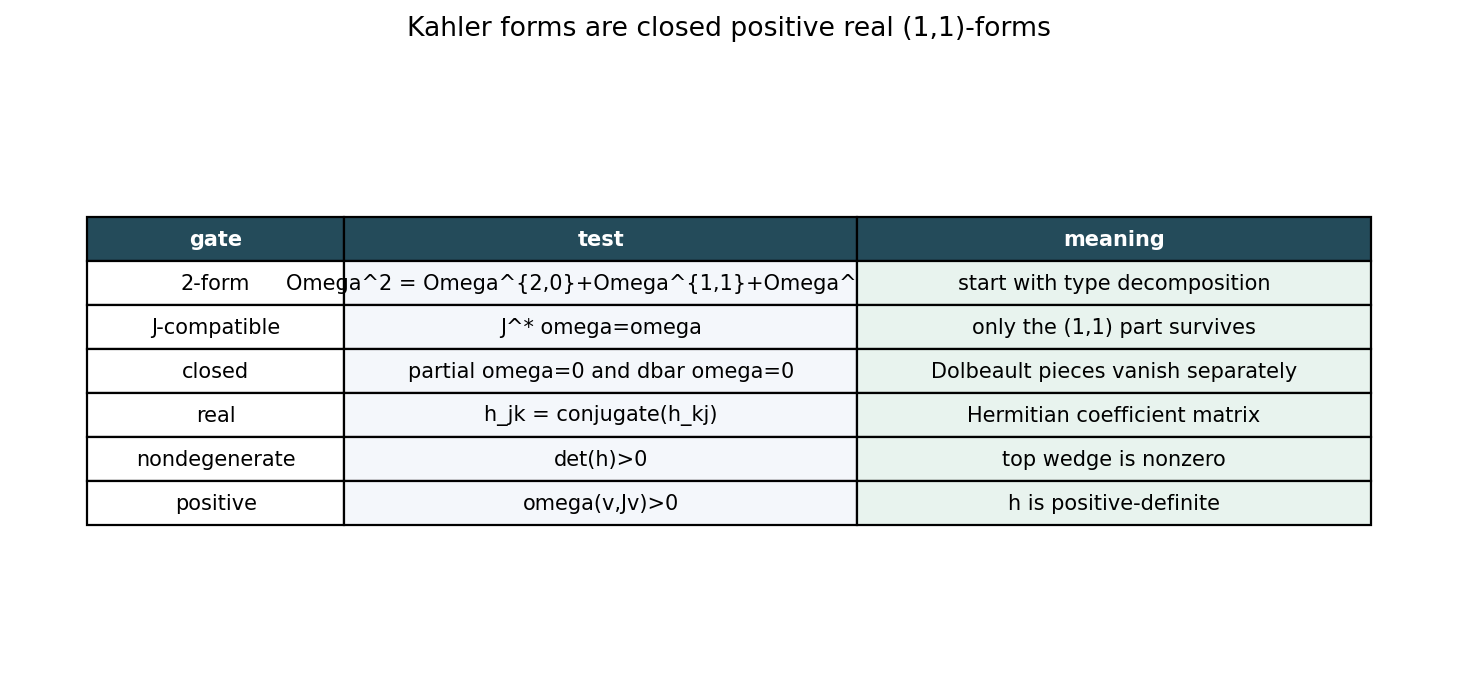

Kahler potentials and Fubini-Study density -> artifacts\lecture-16\figures\kahler-potentials-fubini-study-density.png


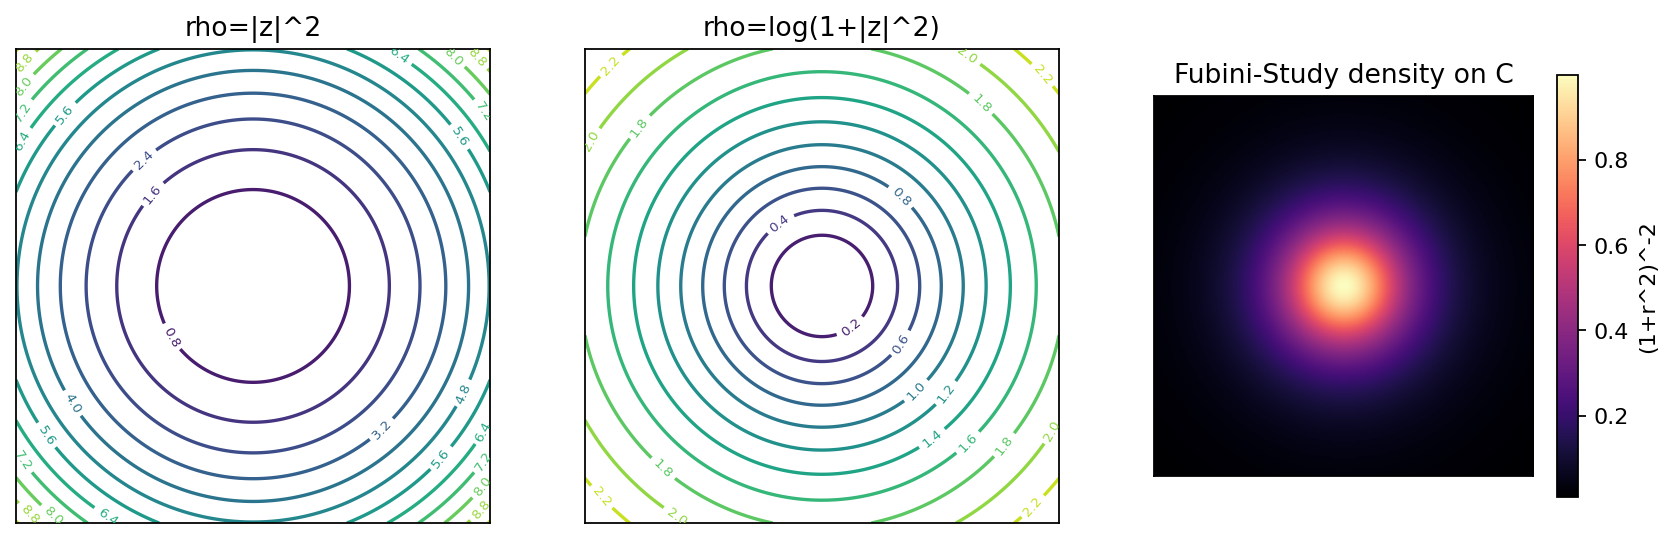

Banyaga-Moser positive path -> artifacts\lecture-16\figures\banyaga-moser-positive-path.png


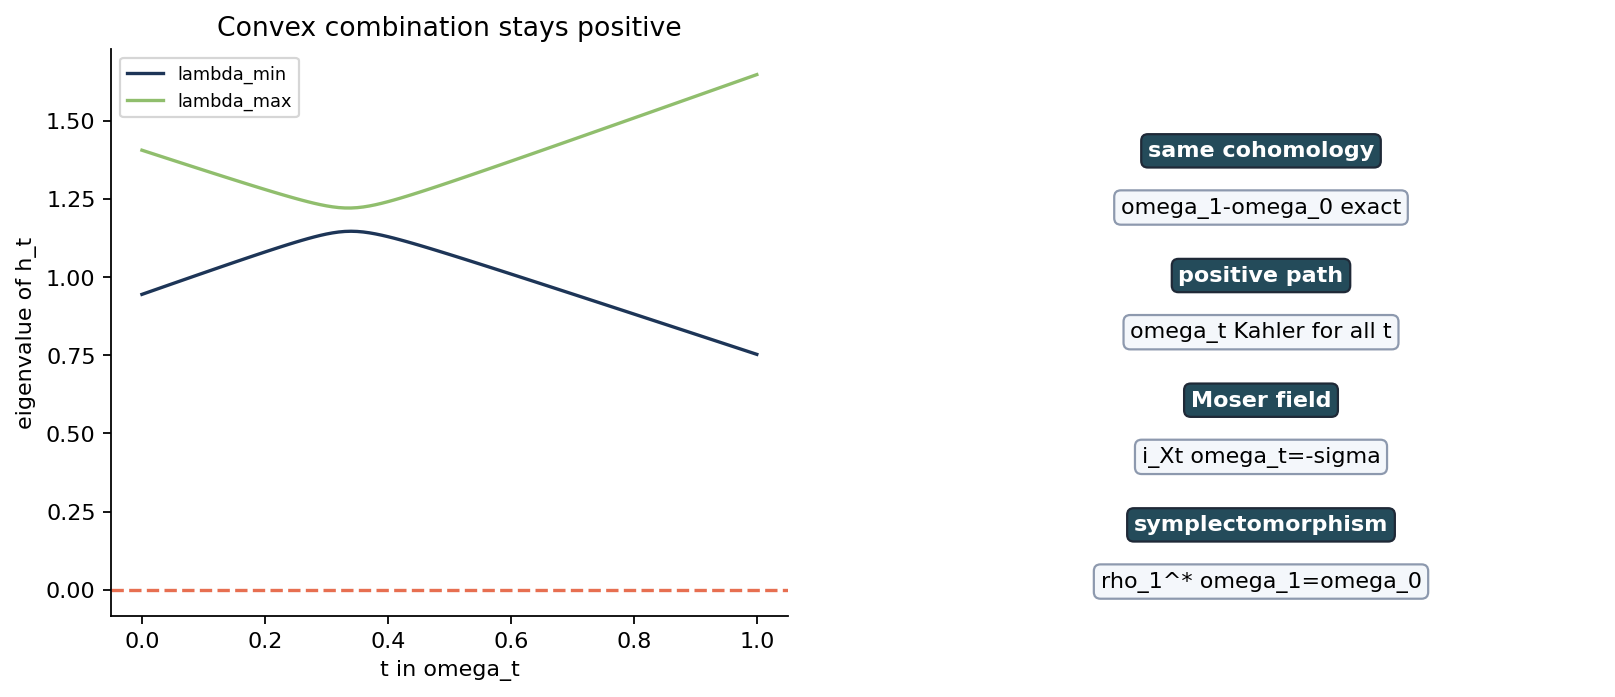

CP1 Fubini-Study area check -> artifacts\lecture-16\figures\cp1-fubini-study-area-check.png


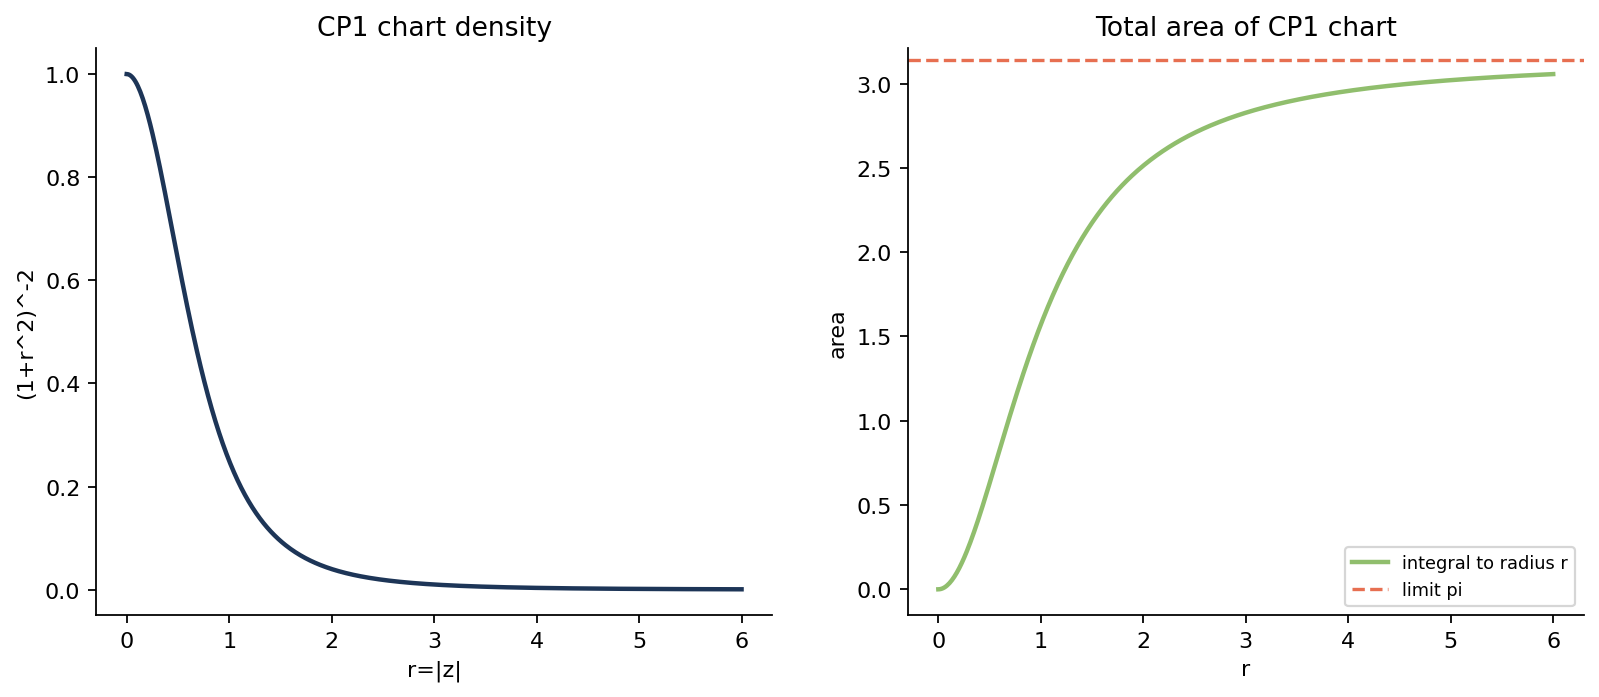

Kahler potential and submanifold route -> artifacts\lecture-16\figures\kahler-potential-submanifold-proof-route.png


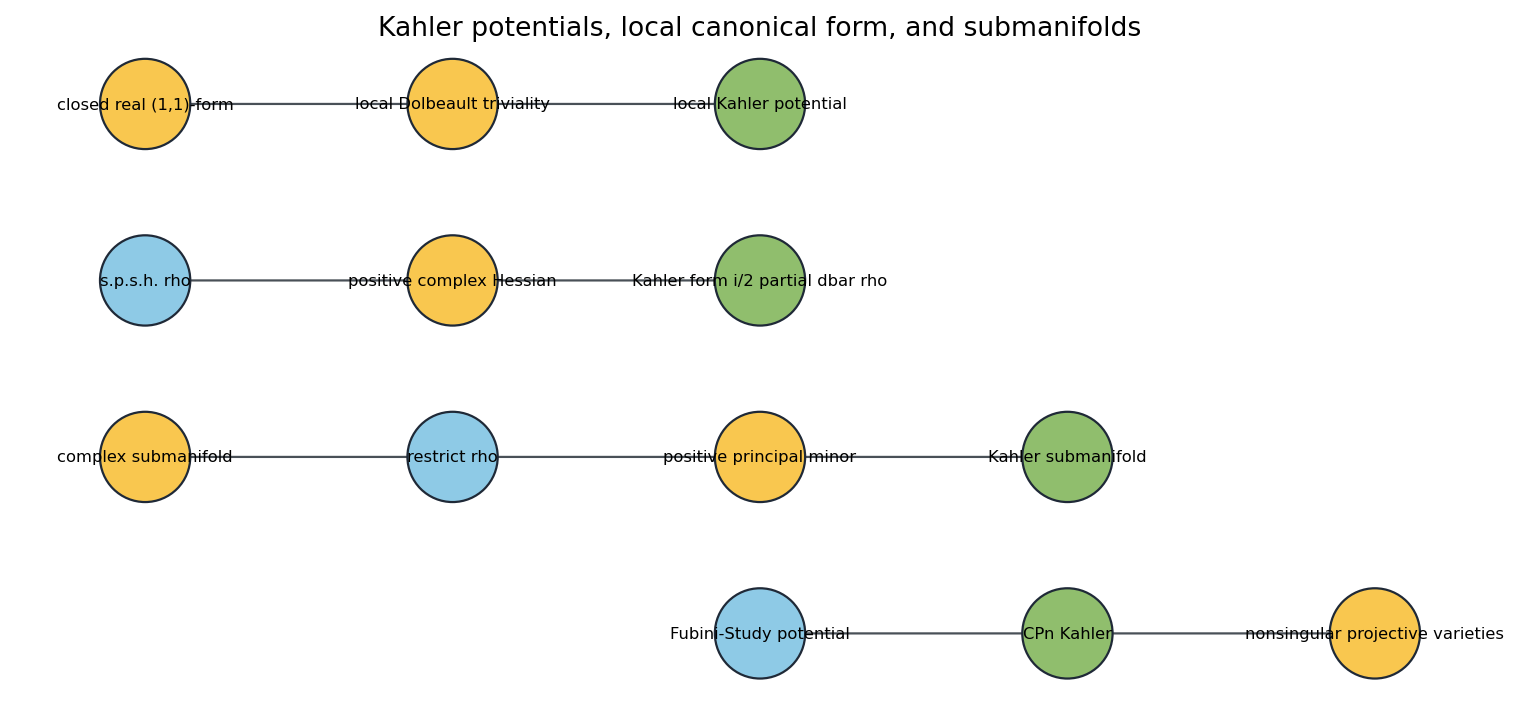

In [9]:
storyboard=read_json(ARTIFACT_ROOT/"checks"/"visual-storyboard.json")
for item in storyboard["visual_sequence"]:
    path=BOOK_ROOT/item["artifact"]
    print(f"{item['concept']} -> {path.relative_to(BOOK_ROOT)}")
    display_artifact(path,width=820)

## Takeaways

- Kahler forms are closed real positive `(1,1)` forms on complex manifolds.
- Compatibility with `J` forces the form into type `(1,1)`; positivity is read from the Hermitian coefficient matrix.
- Strictly plurisubharmonic potentials create Kahler forms by `(i/2) partial dbar rho`.
- Coherent cohomology plus positivity lets Banyaga reduce cohomologous compact Kahler forms to Moser's theorem.
- Locally, closed real `(1,1)` forms have Kahler potentials.
- Complex submanifolds of Kahler manifolds are Kahler, and nonsingular projective varieties inherit this through Fubini-Study geometry.

**Exploration prompt.** Try `rho=log(1+a|z|^2)` in the Hessian check. Vary `a` and predict when the resulting local form stays positive.